#### # Análisis de microbiota con grafos esparsos y dinámica de osciladores

Este cuaderno desarrolla un pipeline completo para analizar datos de microbiota **sin submuestreo**.  El objetivo es clusterizar las muestras usando distintas vistas de similitud (diversidad alfa, CLR–coseno, PPMI) y fusionarlas en un grafo esparso, sobre el cual se simula la dinámica de osciladores de **Kuramoto** para obtener una afinidad de fase y detectar comunidades.

**Requisitos clave:**

- Usar **todas** las OTUs y **todas** las muestras disponibles.
- Evitar densificar matrices de grafos (no usar `.toarray()` sobre grafos grandes).
- Automatizar la detección del archivo OTU y manejar formatos/duplicados.
- Construir las vistas de similitud (alfa, CLR, PPMI) y fusionarlas con pesos.
- Implementar Kuramoto con integrador Heun/RK2 y afinidad de fase en bloques.
- Clusterizar con **Louvain** cuando sea posible; usar **Label Propagation** en caso de error, y **Leiden** opcionalmente.
- Generar visualizaciones y un análisis de estabilidad basado en NMI.


In [2]:

# Bloque 1: Configuración general
import sys
import subprocess
import numpy as np
import pandas as pd
import scipy.sparse as sp
import math
import random
import os
from pathlib import Path
import matplotlib.pyplot as plt

# Función para instalar paquetes silenciosamente
def silent_install(package):
    try:
        __import__(package if package != 'python-louvain' else 'community')
        print(f"{package} ya está instalado.")
        return True
    except Exception:
        try:
            print(f"Instalando {package}…")
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', package, '--quiet'])
            print(f"{package} instalado correctamente.")
            return True
        except Exception as e:
            print(f"No se pudo instalar {package}: {e}")
            return False

# Instalar paquetes requeridos
for pkg in ['networkx', 'python-louvain']:
    silent_install(pkg)
    
# Instalar opcionales
tmp = silent_install('python-igraph')
if tmp:
    silent_install('leidenalg')

# Importar después de instalación

try:
    import networkx as nx
    
    # Verificar si networkx tiene la función from_scipy_sparse_matrix; en versiones mínimas puede faltar
    if not hasattr(nx, 'from_scipy_sparse_matrix'):
        print('NetworkX no soporta from_scipy_sparse_matrix; no se usará.')
        nx = None
except Exception:
    nx = None
try:
    import community as community_louvain
except Exception:
    community_louvain = None
try:
    import igraph as ig
    import leidenalg
except Exception:
    ig = None
    leidenalg = None
from sklearn.metrics import normalized_mutual_info_score

# Semillas y rutas
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
random.seed(GLOBAL_SEED)
PROJECT_ROOT = Path('.').resolve()
DATA_DIR = PROJECT_ROOT / 'Datos'
RESULTS_DIR = PROJECT_ROOT / 'Resultados'
RESULTS_DIR.mkdir(exist_ok=True)

# Parámetros por defecto
TOPK = 12
weights = {'alpha': 0.35, 'ppmi': 0.45, 'clr': 0.20}
Kg_default_vals = np.geomspace(0.7, 1.8, 6)
kuramoto_defaults = dict(dt=0.02, T=1400, burn=500, alpha=0.18, seed=7, normalize_by_degree=True)
phase_affinity_defaults = dict(stride=3, chunk_n=256, use_float32=True)
ANONYMIZE_IDS = False

print(f"Proyecto inicializado en {PROJECT_ROOT}")
print(f"Datos en {DATA_DIR}")
print(f"Resultados en {RESULTS_DIR}")


networkx ya está instalado.
python-louvain ya está instalado.
Instalando python-igraph…
python-igraph instalado correctamente.
leidenalg ya está instalado.
NetworkX no soporta from_scipy_sparse_matrix; no se usará.
Proyecto inicializado en D:\Proyectos\Proyectos Python\Clustering_Microbiota
Datos en D:\Proyectos\Proyectos Python\Clustering_Microbiota\Datos
Resultados en D:\Proyectos\Proyectos Python\Clustering_Microbiota\Resultados


In [3]:

# Bloque 2: Autodescubrimiento del archivo OTU
from pathlib import Path

def guess_otu_path(data_dir: Path):
    
    # Buscar archivo con extensión .otus
    for file in data_dir.iterdir():
        if file.is_file() and file.suffix.lower() == '.otus':
            return file, False
            
    # Buscar archivos que contengan 'otu'
    candidates = []
    for file in data_dir.iterdir():
        if file.is_file() and 'otu' in file.stem.lower() and file.suffix.lower() in {'.tsv', '.csv', '.txt'}:
            candidates.append(file)
    if candidates:
        return candidates[0], False
        
    # Generar sintético
    print("No se encontró archivo OTU; generando datos sintéticos…")
    n_otus, n_samples = 50, 20
    rng = np.random.default_rng(GLOBAL_SEED)
    synthetic_counts = rng.poisson(lam=5, size=(n_otus, n_samples))
    synthetic_path = data_dir / 'synthetic.otus'
    synthetic_df = pd.DataFrame(synthetic_counts, columns=[f'sample_{i:03d}' for i in range(n_samples)])
    synthetic_df.insert(0, 'OTU_ID', [f'OTU_{i:03d}' for i in range(n_otus)])
    synthetic_df.to_csv(synthetic_path, sep='	', index=False)
    return synthetic_path, True

otu_path, synthetic_data = guess_otu_path(DATA_DIR)
print(f"Archivo OTU detectado: {otu_path.name} (sintético={synthetic_data})")


Archivo OTU detectado: otu_data.otus (sintético=False)


In [4]:

# Bloque 3: Lectura robusta del OTU
import pandas as pd
import numpy as np
import scipy.sparse as sp


def load_otu_data(otu_file: Path):
    # Detectar delimitador
    with open(otu_file, 'rb') as f:
        header = f.readline().decode('utf-8', errors='ignore')
        if ',' in header and header.count(',') > header.count('	'):
            delim = ','
        elif '	' in header:
            delim = '	'
        else:
            delim = None
    try:
        df = pd.read_csv(otu_file, sep=delim, engine='python')
    except Exception:
        df = pd.read_csv(otu_file, sep=None, engine='python')
    # Quitar columna taxonomy si existe
    for col in df.columns:
        if col.lower() in {'taxonomy','taxonomyid','tax'}:
            df = df.drop(columns=[col])
            break
    first_col = df.columns[0]
    first_vals = df[first_col].astype(str).values
    def looks_like_sample_id(x):
        return any(c.isalpha() for c in x) and '_' in x
    orientation = 'samples_as_rows' if all(looks_like_sample_id(str(v)) for v in first_vals[:min(len(first_vals), 10)]) else 'otus_as_rows'
    if orientation == 'samples_as_rows':
        sample_ids = df[first_col].astype(str).tolist()
        otu_df = df.drop(columns=[first_col])
        otu_ids = otu_df.columns.astype(str).tolist()
        counts = otu_df.values.astype(float).T
    else:
        otu_ids = df[first_col].astype(str).tolist()
        otu_df = df.drop(columns=[first_col])
        sample_ids = otu_df.columns.astype(str).tolist()
        counts = otu_df.values.astype(float)
    # Agrupar OTUs duplicadas
    if len(set(otu_ids)) != len(otu_ids):
        temp_df = pd.DataFrame(counts, index=otu_ids, columns=sample_ids)
        temp_df = temp_df.groupby(level=0).sum()
        otu_ids = temp_df.index.astype(str).tolist()
        counts = temp_df.values.astype(float)
    # Eliminar OTUs vacías
    counts_sum = counts.sum(axis=1)
    mask_nonzero = counts_sum > 0
    counts = counts[mask_nonzero]
    otu_ids = [otu_ids[i] for i, flag in enumerate(mask_nonzero) if flag]
    # Unicidad de sample_ids
    seen = {}
    uniq_sample_ids = []
    for sid in sample_ids:
        if sid not in seen:
            seen[sid] = 1
            uniq_sample_ids.append(sid)
        else:
            seen[sid] += 1
            uniq_sample_ids.append(f"{sid}_{seen[sid]}")
    sample_ids = uniq_sample_ids
    counts_matrix = sp.csr_matrix(counts)
    print(f"OTU cargado: {counts_matrix.shape[0]} OTUs x {counts_matrix.shape[1]} muestras")
    return counts_matrix, otu_ids, sample_ids

counts_matrix, otu_ids, sample_ids = load_otu_data(otu_path)

df_preview = pd.DataFrame(
    counts_matrix[:6, :6].toarray(),
    index=otu_ids[:6],
    columns=sample_ids[:6]
)
print("\nVista previa de los primeros datos cargados:")
print(df_preview)


OTU cargado: 4720 OTUs x 441 muestras

Vista previa de los primeros datos cargados:
          MI_001_H  MI_002_H  MI_003_H  MI_004_H  MI_005_H  MI_006_H
Otu00001     354.0     168.0      19.0     264.0       0.0       3.0
Otu00002     817.0       9.0     174.0    1816.0       2.0       0.0
Otu00003      50.0     131.0    6211.0     159.0       0.0    3536.0
Otu00004      31.0    3005.0      79.0      16.0      12.0      38.0
Otu00005     448.0      68.0    1063.0     110.0     598.0     815.0
Otu00006     547.0   10187.0       0.0       4.0      39.0    1270.0


In [5]:
# Bloque 4: Métricas alfa y similitud
import numpy as np
import pandas as pd


def compute_alpha_metrics(counts: sp.csr_matrix, otu_ids, sample_ids):
    X = counts.toarray()
    X_samp = X.T
    richness = (X_samp > 0).sum(axis=1)
    row_sums = X_samp.sum(axis=1)
    ps = X_samp + 1e-12
    ps = ps / row_sums[:, None]
    shannon = -np.sum(ps * np.log(ps + 1e-16), axis=1)
    simpson = 1.0 - np.sum(ps**2, axis=1)
    alpha_df = pd.DataFrame({'sample_id': sample_ids, 'richness': richness, 'shannon': shannon, 'simpson': simpson})
    for col in ['richness','shannon','simpson']:
        m = alpha_df[col].mean()
        s = alpha_df[col].std(ddof=1)
        alpha_df[col+'_z'] = (alpha_df[col] - m) / (s + 1e-8)
    X_z = alpha_df[['richness_z','shannon_z','simpson_z']].values
    norms = np.linalg.norm(X_z, axis=1)
    norms[norms==0] = 1.0
    X_norm = X_z / norms[:,None]
    sim_alpha = X_norm @ X_norm.T
    np.fill_diagonal(sim_alpha,0.0)
    return sim_alpha, alpha_df

sim_alpha, alpha_df = compute_alpha_metrics(counts_matrix, otu_ids, sample_ids)
print("Matriz de similitud alfa calculada.")

print("\n Métricas alfa por muestra:")
print(alpha_df[['sample_id', 'richness', 'shannon', 'simpson']].head().round(3))

# Mostrar pequeña porción de la matriz de similitud 
n_preview = 6
sub_ids = alpha_df['sample_id'][:n_preview]
sub_sim = sim_alpha[:n_preview, :n_preview]
sub_df = pd.DataFrame(sub_sim, index=sub_ids, columns=sub_ids)

print("\n Submatriz de similitud alfa:")
print(sub_df.round(3))

# Vista rápida del rango de similitudes
print(f"\nRango de similitud: {sim_alpha.min():.3f} a {sim_alpha.max():.3f}")




Matriz de similitud alfa calculada.

 Métricas alfa por muestra:
  sample_id  richness  shannon  simpson
0  MI_001_H       259    3.957    0.959
1  MI_002_H       398    3.445    0.907
2  MI_003_H       127    2.709    0.887
3  MI_004_H       179    3.667    0.935
4  MI_005_H       143    3.510    0.945

 Submatriz de similitud alfa:
sample_id  MI_001_H  MI_002_H  MI_003_H  MI_004_H  MI_005_H  MI_006_H
sample_id                                                            
MI_001_H      0.000     0.434    -0.422     0.616     0.339     0.732
MI_002_H      0.434     0.000    -0.953    -0.440    -0.685     0.932
MI_003_H     -0.422    -0.953     0.000     0.432     0.700    -0.889
MI_004_H      0.616    -0.440     0.432     0.000     0.946    -0.084
MI_005_H      0.339    -0.685     0.700     0.946     0.000    -0.380
MI_006_H      0.732     0.932    -0.889    -0.084    -0.380     0.000

Rango de similitud: -1.000 a 1.000


In [6]:

# Bloque 5: Cálculo de CLR y PPMI
import numpy as np
import scipy.sparse as sp


def compute_clr_similarity(counts: sp.csr_matrix):
    X = counts.toarray()
    X_pseudo = X + 1.0
    prop = X_pseudo / X_pseudo.sum(axis=0, keepdims=True)
    log_prop = np.log(prop)
    clr = log_prop - log_prop.mean(axis=0, keepdims=True)
    Xclr = clr.T
    norms = np.linalg.norm(Xclr, axis=1)
    norms[norms==0] = 1.0
    Xclr_norm = Xclr / norms[:,None]
    sim_clr = Xclr_norm @ Xclr_norm.T
    np.fill_diagonal(sim_clr,0.0)
    return sim_clr

def compute_ppmi_similarity(counts: sp.csr_matrix):
    X = counts.astype(float)
    total = X.sum()
    row_sum = np.array(X.sum(axis=1)).flatten()
    col_sum = np.array(X.sum(axis=0)).flatten()
    X_coo = X.tocoo()
    expected = (row_sum[X_coo.row] * col_sum[X_coo.col]) / total
    with np.errstate(divide='ignore', invalid='ignore'):
        ppmi_data = np.log((X_coo.data * total) / expected)
    ppmi_data[~np.isfinite(ppmi_data)] = 0.0
    ppmi_data = np.maximum(0.0, ppmi_data)
    ppmi_matrix = sp.csr_matrix((ppmi_data, (X_coo.row, X_coo.col)), shape=X.shape)
    M = (ppmi_matrix.T @ ppmi_matrix).toarray()
    norms = np.sqrt(np.diag(M))
    norms[norms==0] = 1.0
    sim_ppmi = M / (norms[:,None] * norms[None,:])
    np.fill_diagonal(sim_ppmi,0.0)
    return sim_ppmi

sim_clr = compute_clr_similarity(counts_matrix)
print("Similitud CLR calculada.")
sim_ppmi = compute_ppmi_similarity(counts_matrix)
print("Similitud PPMI calculada.")

print("\nMatriz de similitud CLR calculada.")

# Mostrar pequeña porción de la matriz de similitud CLR
n_preview = 6
sub_ids = sample_ids[:n_preview]
sub_clr = sim_clr[:n_preview, :n_preview]
sub_df_clr = pd.DataFrame(sub_clr, index=sub_ids, columns=sub_ids)

print("\n Submatriz de similitud CLR:")
print(sub_df_clr.round(3))

# Vista rápida del rango de similitudes
print(f"\nRango de similitud CLR: {sim_clr.min():.3f} a {sim_clr.max():.3f}")

# -----------------------------------------------------

print("\nMatriz de similitud PPMI calculada.")

# Mostrar pequeña porción de la matriz de similitud PPMI
sub_ppmi = sim_ppmi[:n_preview, :n_preview]
sub_df_ppmi = pd.DataFrame(sub_ppmi, index=sub_ids, columns=sub_ids)

print("\n Submatriz de similitud PPMI:")
print(sub_df_ppmi.round(3))

# Vista rápida del rango de similitudes
print(f"\nRango de similitud PPMI: {sim_ppmi.min():.3f} a {sim_ppmi.max():.3f}")

Similitud CLR calculada.
Similitud PPMI calculada.

Matriz de similitud CLR calculada.

 Submatriz de similitud CLR:
          MI_001_H  MI_002_H  MI_003_H  MI_004_H  MI_005_H  MI_006_H
MI_001_H     0.000     0.542     0.523     0.549     0.326     0.574
MI_002_H     0.542     0.000     0.423     0.430     0.234     0.573
MI_003_H     0.523     0.423     0.000     0.570     0.337     0.486
MI_004_H     0.549     0.430     0.570     0.000     0.343     0.481
MI_005_H     0.326     0.234     0.337     0.343     0.000     0.242
MI_006_H     0.574     0.573     0.486     0.481     0.242     0.000

Rango de similitud CLR: 0.000 a 0.906

Matriz de similitud PPMI calculada.

 Submatriz de similitud PPMI:
          MI_001_H  MI_002_H  MI_003_H  MI_004_H  MI_005_H  MI_006_H
MI_001_H     0.000     0.419     0.341     0.415     0.261     0.454
MI_002_H     0.419     0.000     0.271     0.335     0.238     0.423
MI_003_H     0.341     0.271     0.000     0.426     0.326     0.290
MI_004_H     0.41

In [7]:
sim_fused = (sim_alpha + sim_ppmi + sim_clr) / 3.0
print(sim_fused)

[[ 0.          0.46517979  0.14715948 ...  0.70629251  0.16590487
   0.42520372]
 [ 0.46517979  0.         -0.08629883 ...  0.42345127  0.00978143
   0.01154354]
 [ 0.14715948 -0.08629883  0.         ...  0.08544358  0.60652746
   0.48199243]
 ...
 [ 0.70629251  0.42345127  0.08544358 ...  0.          0.14050466
   0.44206286]
 [ 0.16590487  0.00978143  0.60652746 ...  0.14050466  0.
   0.42284532]
 [ 0.42520372  0.01154354  0.48199243 ...  0.44206286  0.42284532
   0.        ]]


Simulando Kuramoto sobre sim_fused (sin k-NN) | Kg=0.7, PRESERVAR_SIGNO=True, MODO_ESCALADO='max_abs' ...
Afinidad de fase calculada: mean=0.0019, std=0.2236

================= RESULTADOS KURAMOTO =================
1️⃣ phases_example: matriz de fases (T_burn x N) = (900, 441)
   - Muestra el ángulo de cada nodo en cada paso temporal (rango 0–2π).
   - Ejemplo primeras filas:
[[ -6.386  -7.289   4.673  10.412 -13.48 ]
 [ -6.407  -7.314   4.673  10.431 -13.51 ]
 [ -6.429  -7.34    4.673  10.449 -13.541]]

2️⃣ r_values: vector del orden global (sincronía) = (1400,)
   - Mide el grado de sincronización del sistema en el tiempo.
   - Primeros 10 valores: [0.0398 0.0407 0.0416 0.0426 0.0435 0.0444 0.0453 0.0463 0.0472 0.0481]

3️⃣ aff_example: matriz de afinidad de fase (N x N) = (441, 441)
   - Representa la similitud promedio entre fases (1 = muy sincronizados).
   - Estadísticas -> min: -0.997, max: 0.999, mean: 0.002, std: 0.224

🧩 Vista parcial de aff_example (primeros 10 nodos):
Matriz

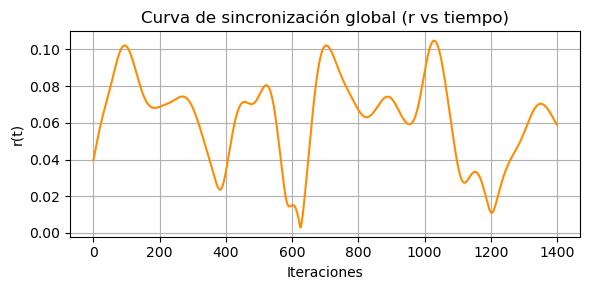

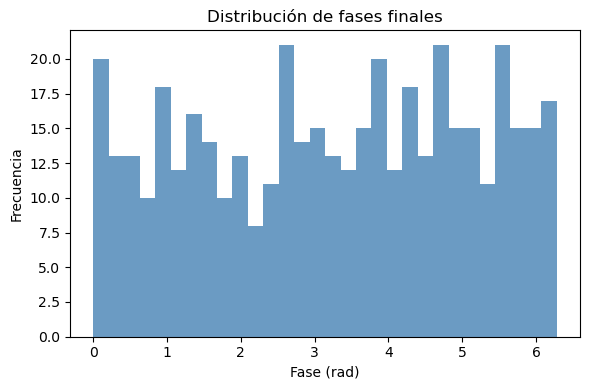

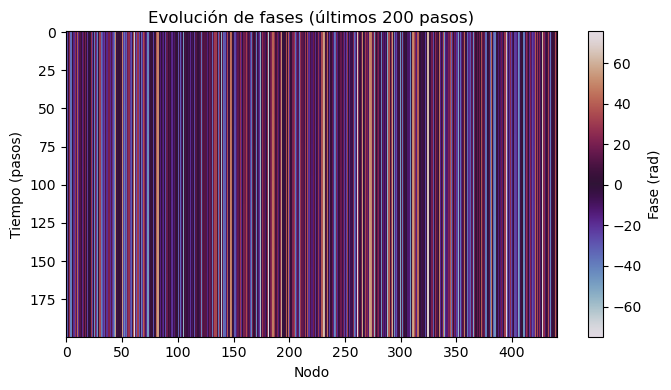

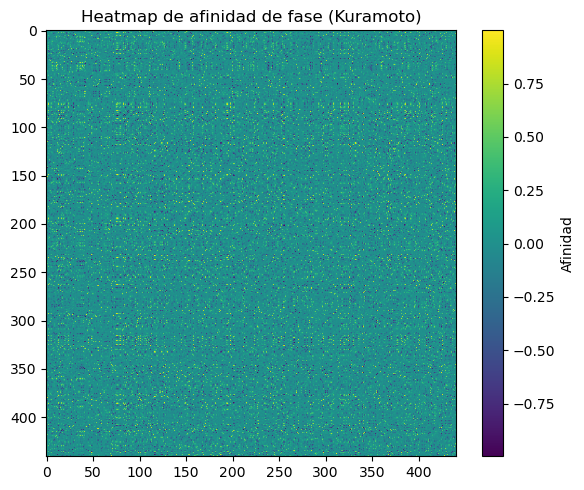

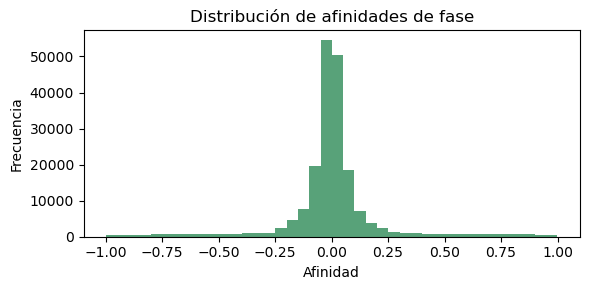

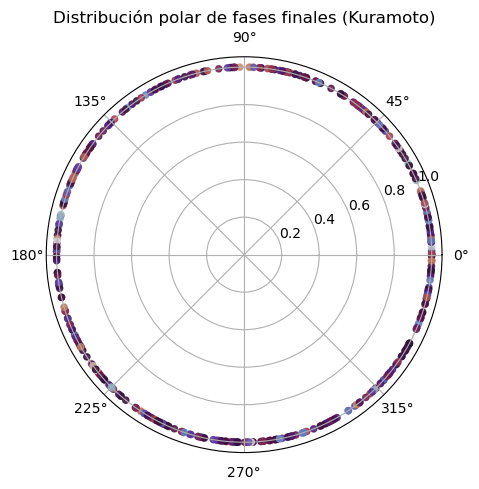

In [8]:
# ================================================================
# 6. Kuramoto sobre sim_fused (sin k-NN) con previsualización
# ================================================================
import numpy as np
import scipy.sparse as sp
import math
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# CONFIGURACIÓN
# ------------------------------------------------------------------
PRESERVAR_SIGNO = True
MODO_ESCALADO = "max_abs"
UMBRAL_MIN = None

try:
    _ = kuramoto_defaults
except NameError:
    kuramoto_defaults = dict(dt=0.05, T=1200, burn=600, alpha=0.18, seed=7, normalize_by_degree=True)

try:
    _ = phase_affinity_defaults
except NameError:
    phase_affinity_defaults = dict(stride=3, chunk_n=256, use_float32=True)

try:
    Kg_example = Kg_default_vals[0]
except NameError:
    Kg_example = 0.1

# ------------------------------------------------------------------
# 1) Preparar matriz de acoplamientos desde sim_fused (densa -> CSR)
# ------------------------------------------------------------------
A = np.asarray(sim_fused, dtype=float)
A = np.nan_to_num(A, nan=0.0, posinf=0.0, neginf=0.0)
np.fill_diagonal(A, 0.0)
A = 0.5 * (A + A.T)

if not PRESERVAR_SIGNO:
    A = np.clip(A, 0.0, None)

if MODO_ESCALADO == "max_abs":
    denom = np.max(np.abs(A)) if PRESERVAR_SIGNO else np.max(A)
    if denom > 0:
        A = A / denom
elif MODO_ESCALADO == "fila":
    row_sums = np.sum(np.abs(A), axis=1, keepdims=True) if PRESERVAR_SIGNO else np.sum(A, axis=1, keepdims=True)
    row_sums = np.maximum(row_sums, 1e-12)
    A = A / row_sums
else:
    raise ValueError("MODO_ESCALADO debe ser 'max_abs' o 'fila'.")

if UMBRAL_MIN is not None and UMBRAL_MIN > 0:
    A[np.abs(A) < UMBRAL_MIN] = 0.0

W_simfused_full = sp.csr_matrix(A)

# ------------------------------------------------------------------
# 2) Kuramoto y afinidad de fase
# ------------------------------------------------------------------
def simulate_kuramoto(W: sp.csr_matrix, Kg: float, dt: float, T: int, burn: int,
                      alpha: float = 0.18, seed: int = 7, normalize_by_degree: bool = True):
    n = W.shape[0]
    rng = np.random.default_rng(seed)
    theta = rng.uniform(0.0, 2.0 * math.pi, size=n)
    natural = rng.normal(loc=0.0, scale=1.0, size=n)

    neighbors, weights_list = [], []
    degrees = np.array(W.sum(axis=1)).flatten()
    for i in range(n):
        start, end = W.indptr[i], W.indptr[i+1]
        neighbors.append(W.indices[start:end])
        weights_list.append(W.data[start:end])

    phases = []
    r_values = []

    for step in range(T):
        dtheta = np.zeros(n, dtype=float)
        for i in range(n):
            if len(neighbors[i]) == 0:
                continue
            diffs = theta[neighbors[i]] - theta[i]
            coupling = (Kg / (degrees[i] if degrees[i] > 0 else 1.0)) if normalize_by_degree else Kg
            dtheta[i] = natural[i] + coupling * np.sum(weights_list[i] * np.sin(diffs))

        # Heun integration
        k1 = dtheta
        theta_pred = theta + dt * k1

        dtheta2 = np.zeros(n, dtype=float)
        for i in range(n):
            if len(neighbors[i]) == 0:
                continue
            diffs2 = theta_pred[neighbors[i]] - theta_pred[i]
            coupling = (Kg / (degrees[i] if degrees[i] > 0 else 1.0)) if normalize_by_degree else Kg
            dtheta2[i] = natural[i] + coupling * np.sum(weights_list[i] * np.sin(diffs2))

        theta = theta + dt * dtheta2

        # Guardar fase y orden global
        r = np.abs(np.mean(np.exp(1j * theta)))
        r_values.append(r)
        if step >= burn:
            phases.append(theta.copy())

    return np.array(phases), np.array(r_values)

def phase_affinity(phases: np.ndarray, stride: int = 3, chunk_n: int = 256, use_float32: bool = True):
    dtype = np.float32 if use_float32 else np.float64
    phases_sub = phases[::stride]
    n_time, n_nodes = phases_sub.shape
    cos_vals = np.cos(phases_sub).astype(dtype)
    sin_vals = np.sin(phases_sub).astype(dtype)
    aff = np.zeros((n_nodes, n_nodes), dtype=dtype)
    for start in range(0, n_nodes, chunk_n):
        end = min(start + chunk_n, n_nodes)
        C = cos_vals.T @ cos_vals[:, start:end]
        S = sin_vals.T @ sin_vals[:, start:end]
        aff[:, start:end] = (C + S) / n_time
    aff = np.maximum(aff, aff.T)
    np.fill_diagonal(aff, 0.0)
    return aff

# ------------------------------------------------------------------
# 3) Simulación
# ------------------------------------------------------------------
print(f"Simulando Kuramoto sobre sim_fused (sin k-NN) | Kg={Kg_example}, "
      f"PRESERVAR_SIGNO={PRESERVAR_SIGNO}, MODO_ESCALADO='{MODO_ESCALADO}' ...")

phases_example, r_values = simulate_kuramoto(
    W_simfused_full,
    Kg=Kg_example,
    dt=kuramoto_defaults['dt'],
    T=kuramoto_defaults['T'],
    burn=kuramoto_defaults['burn'],
    alpha=kuramoto_defaults['alpha'],
    seed=kuramoto_defaults['seed'],
    normalize_by_degree=kuramoto_defaults['normalize_by_degree'],
)

aff_example = phase_affinity(
    phases_example,
    stride=phase_affinity_defaults['stride'],
    chunk_n=phase_affinity_defaults['chunk_n'],
    use_float32=phase_affinity_defaults['use_float32'],
)

print(f"Afinidad de fase calculada: mean={aff_example.mean():.4f}, std={aff_example.std():.4f}")

# ------------------------------------------------------------------
# 5) RESUMEN DE RESULTADOS (matrices y vectores)
# ------------------------------------------------------------------
print("\n================= RESULTADOS KURAMOTO =================")
print(f"1️⃣ phases_example: matriz de fases (T_burn x N) = {phases_example.shape}")
print(f"   - Muestra el ángulo de cada nodo en cada paso temporal (rango 0–2π).")
print(f"   - Ejemplo primeras filas:\n{np.round(phases_example[:3, :5], 3)}\n")

print(f"2️⃣ r_values: vector del orden global (sincronía) = {r_values.shape}")
print(f"   - Mide el grado de sincronización del sistema en el tiempo.")
print(f"   - Primeros 10 valores: {np.round(r_values[:10], 4)}\n")

print(f"3️⃣ aff_example: matriz de afinidad de fase (N x N) = {aff_example.shape}")
print(f"   - Representa la similitud promedio entre fases (1 = muy sincronizados).")
print(f"   - Estadísticas -> min: {aff_example.min():.3f}, max: {aff_example.max():.3f}, "
      f"mean: {aff_example.mean():.3f}, std: {aff_example.std():.3f}")
n_preview = 10  # número de filas y columnas a mostrar
n_total = aff_example.shape[0]
n_show = min(n_preview, n_total)

print(f"\n🧩 Vista parcial de aff_example (primeros {n_show} nodos):")
print(f"Matriz de tamaño total: {aff_example.shape}")

df_preview = pd.DataFrame(
    np.round(aff_example[:n_show, :n_show], 3),
    columns=[f"n{j}" for j in range(n_show)],
    index=[f"n{i}" for i in range(n_show)]
)
print(df_preview)
print("=========================================================\n")

# ------------------------------------------------------------------
# 4) PREVISUALIZACIONES DE RESULTADOS
# ------------------------------------------------------------------
plt.figure(figsize=(6, 3))
plt.plot(r_values, color="darkorange")
plt.title("Curva de sincronización global (r vs tiempo)")
plt.xlabel("Iteraciones")
plt.ylabel("r(t)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Fases finales
final_phases = phases_example[-1]
plt.figure(figsize=(6, 4))
plt.hist(final_phases % (2*np.pi), bins=30, color="steelblue", alpha=0.8)
plt.title("Distribución de fases finales")
plt.xlabel("Fase (rad)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# Mapa de calor de fases (últimos 200 pasos)
n_show = min(200, phases_example.shape[0])
plt.figure(figsize=(7, 4))
plt.imshow(phases_example[-n_show:], aspect='auto', cmap='twilight', interpolation='nearest')
plt.title(f"Evolución de fases (últimos {n_show} pasos)")
plt.xlabel("Nodo")
plt.ylabel("Tiempo (pasos)")
plt.colorbar(label="Fase (rad)")
plt.tight_layout()
plt.show()

# Heatmap de afinidad de fase
plt.figure(figsize=(6, 5))
plt.imshow(aff_example, cmap="viridis", aspect="auto")
plt.title("Heatmap de afinidad de fase (Kuramoto)")
plt.colorbar(label="Afinidad")
plt.tight_layout()
plt.show()

# Histograma de afinidades
plt.figure(figsize=(6, 3))
plt.hist(aff_example.flatten(), bins=40, color="seagreen", alpha=0.8)
plt.title("Distribución de afinidades de fase")
plt.xlabel("Afinidad")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# Gráfico polar de fases finales (clusters visuales)
fig, ax = plt.subplots(figsize=(5, 5), subplot_kw={'projection': 'polar'})
ax.scatter(final_phases % (2*np.pi), np.ones_like(final_phases),
           s=20, c=final_phases, cmap='twilight', alpha=0.85)
ax.set_title("Distribución polar de fases finales (Kuramoto)")
plt.tight_layout()
plt.show()

# ================================================================


[Kuramoto puro] Clusters: 1 | Tamaños: [441]


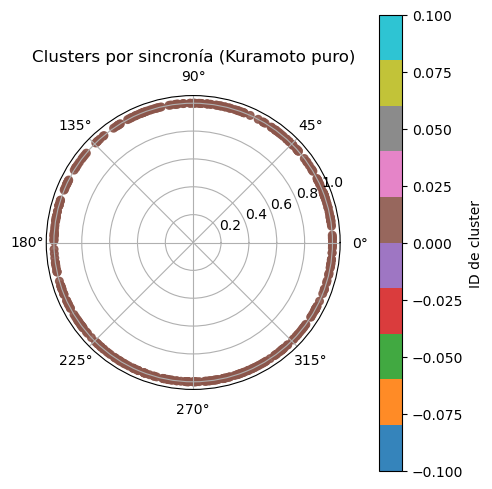

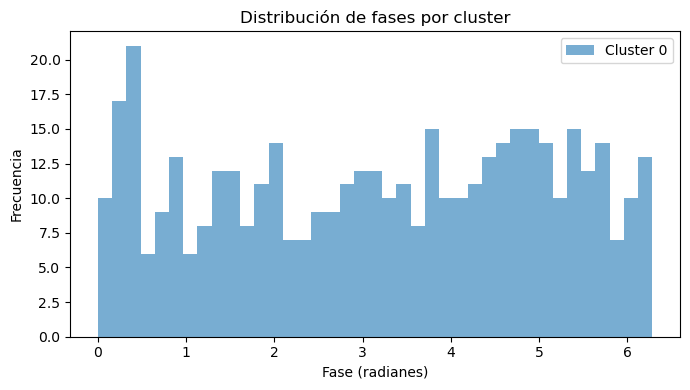

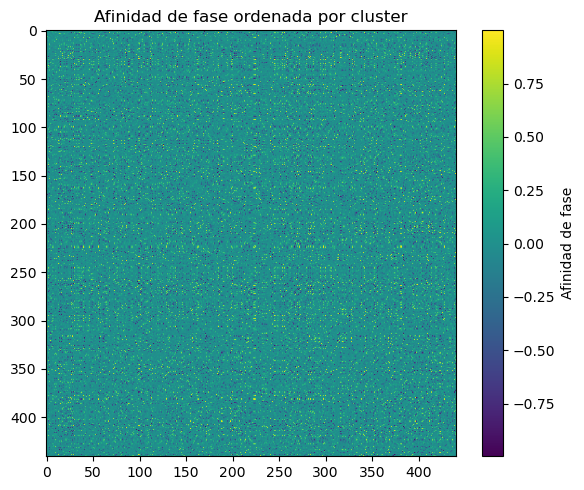

In [10]:
#umbral angular y componente conexa

import numpy as np
import scipy.sparse as sp
from scipy.sparse.csgraph import connected_components

# 1) Fase “estable” (promedio de las últimas L iteraciones)
L = min(200, phases_example.shape[0])
phi = np.angle(np.mean(np.exp(1j*phases_example[-L:]), axis=0))  # (N,)

# 2) Adyacencia por proximidad angular
delta = 0.35  # umbral en radianes (≈20°). Ajusta 0.25–0.45 según tu caso.
N = phi.size
rows, cols = [], []
for i in range(N):
    dphi = np.abs(np.angle(np.exp(1j*(phi - phi[i]))))  # |Δθ| en [0,π]
    idx = np.where((dphi <= delta) & (np.arange(N) != i))[0]
    rows.extend([i]*len(idx))
    cols.extend(idx.tolist())

A_phase = sp.csr_matrix((np.ones(len(rows)), (rows, cols)), shape=(N, N))
A_phase = A_phase.maximum(A_phase.T)  # simétrico

# 3) Componentes conexas = clusters
n_comp, labels = connected_components(A_phase, directed=False)
print(f"[Kuramoto puro] Clusters: {n_comp} | Tamaños:", np.bincount(labels))

#Vsualizaciones

import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
ax = plt.subplot(111, projection='polar')
scatter = ax.scatter(phi % (2*np.pi), np.ones_like(phi),
                     c=labels, cmap='tab10', s=30, alpha=0.9)
ax.set_title("Clusters por sincronía (Kuramoto puro)")
plt.colorbar(scatter, label="ID de cluster", pad=0.1)
plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
bins = np.linspace(0, 2*np.pi, 40)
for lab in np.unique(labels):
    subset = phi[labels == lab] % (2*np.pi)
    plt.hist(subset, bins=bins, alpha=0.6, label=f"Cluster {lab}")
plt.title("Distribución de fases por cluster")
plt.xlabel("Fase (radianes)")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.show()

import numpy as np
import matplotlib.pyplot as plt

order = np.argsort(labels)
plt.figure(figsize=(6,5))
plt.imshow(aff_example[order][:,order], cmap='viridis', aspect='auto')
plt.title("Afinidad de fase ordenada por cluster")
plt.colorbar(label="Afinidad de fase")
plt.tight_layout()
plt.show()



[Kuramoto puro] Clusters: 18 | Tamaños: [35 20 26 18 23 25 15 19 31 20 25 23 25 32 30 26 25 23]


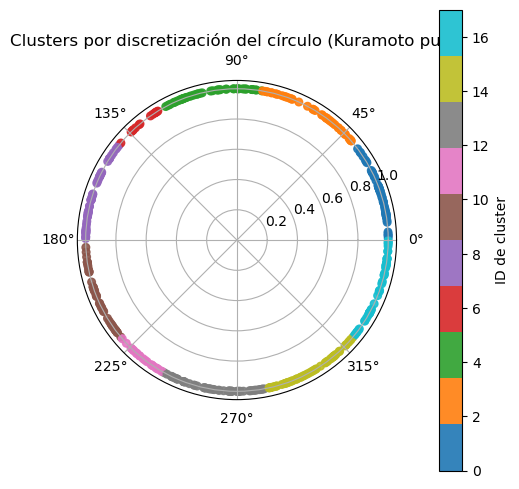

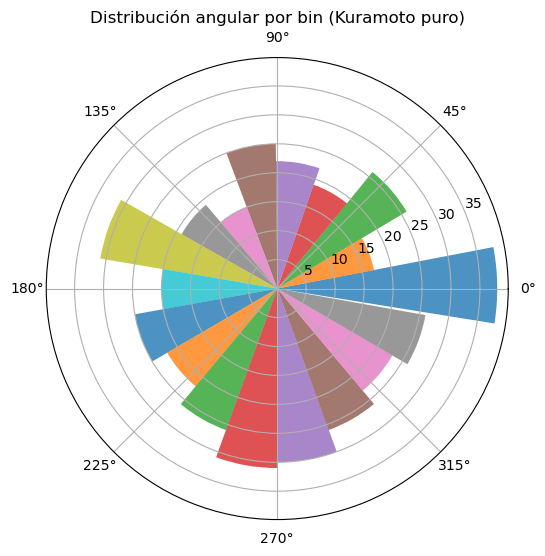

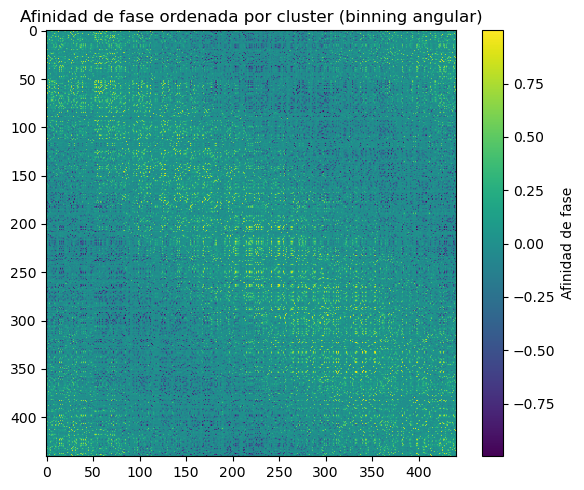

In [12]:
#discretizacion del circulo 

# 1) Fase “estable”
L = min(200, phases_example.shape[0])
phi = np.angle(np.mean(np.exp(1j*phases_example[-L:]), axis=0))  # (N,)

# 2) Bins angulares
delta_bin = 0.35  # ancho del bin en radianes (≈20°)
bins = np.floor(((phi % (2*np.pi)) / delta_bin)).astype(int)

# 3) Etiquetas de cluster = índice de bin
labels = bins - bins.min()  # reindexa a 0..K-1
print(f"[Kuramoto puro] Clusters: {labels.max()+1} | Tamaños:", np.bincount(labels))

#Vsualizacion

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(5,5))
ax = plt.subplot(111, projection='polar')
scatter = ax.scatter(phi % (2*np.pi), np.ones_like(phi),
                     c=labels, cmap='tab10', s=30, alpha=0.9)
ax.set_title("Clusters por discretización del círculo (Kuramoto puro)")
plt.colorbar(scatter, label="ID de cluster", pad=0.1)
plt.tight_layout()
plt.show()

# histograma polar
plt.figure(figsize=(6,6))
ax = plt.subplot(111, projection='polar')

n_bins = labels.max() + 1
counts, edges = np.histogram(phi % (2*np.pi), bins=n_bins)
width = 2*np.pi / n_bins
ax.bar(edges[:-1], counts, width=width, color=plt.cm.tab10(np.arange(n_bins) % 10), alpha=0.8)
ax.set_title("Distribución angular por bin (Kuramoto puro)")
plt.show()

order = np.argsort(labels)
plt.figure(figsize=(6,5))
plt.imshow(aff_example[order][:,order], cmap='viridis', aspect='auto')
plt.title("Afinidad de fase ordenada por cluster (binning angular)")
plt.colorbar(label="Afinidad de fase")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.cluster import SpectralClustering
clust = SpectralClustering(n_clusters=k, affinity='precomputed').fit(aff_example)


In [9]:
import igraph as ig
g = ig.Graph.Weighted_Adjacency(aff_example.tolist(), mode="undirected", attr="weight")
communities = g.community_leiden(weights="weight")
